![Ironhack logo](https://user-images.githubusercontent.com/23629340/40541063-a07a0a8a-601a-11e8-91b5-2f13e4e6b441.png)

# 02 | Processing and Database Design

*Project 1 — SQL: From Data to Insight*

**Team:**
**Dataset:**

---

Turning one flat file into a relational database: clean the data, split it into tables, wire up the keys, load it into SQLite.

> **Done when:** `data/project.db` exists with 3+ related tables, `sql/schema.sql` matches your ERD, no foreign key is dangling, and the row counts are what you expect.

The sections below are a suggested route, not a form to fill in. Add sections, drop them, reorder them — what is graded is the analysis, not whether you kept the scaffold.

---
## 0. Setup

In [2]:
import sys
sys.path.append("..")          # so `src` is importable from inside notebooks/

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.functions import *

pd.set_option("display.max_columns", 100)
sns.set_theme(style="whitegrid")

---
## 1. Load the raw data

In [3]:
# Puting all private info in extra file, so its not available for public and than retrieving it
from dotenv import load_dotenv
import os

load_dotenv()

data_path = os.getenv("DATA_PATH")

if data_path is None:
    raise ValueError("DATA_PATH is not set. Create a .env file first.")

In [4]:
raw_data = data_path

In [5]:
df = pd.read_excel(raw_data)

In [6]:
df.head()

,year,country,countryn,iso,iso3n,cpds1,poco,eu,emu,gov_right1,gov_cent1,gov_left1,gov_party,gov_new,gov_gap,gov_chan,gov_right2,gov_cent2,gov_left2,gov_right3,gov_cent3,gov_left3,gov_sup,gov_type,year_01,country_01,elect,vturn,social1,social2,social3,social4,social5,social6,social7,social8,social9,leftsoc1,leftsoc2,leftsoc3,leftsoc4,leftsoc5,comm1,comm2,comm3,comm4,postcom1,postcom2,agrarian1,agrarian2,...,survivor_pmp,incapben_pmp,health_pmp,family_pmp,almp_pmp,unemp_pmp,housing_pmp,othsocx_pmp,year_10,country_10,educexp_gov,educexp_gov_ipol,educexp_public,educexp_public_ipol,educexp_private,educexp_private_ipol,educatt_minimal,educatt_minimal_ipol,educatt_tertiary,educatt_tertiary_ipol,year_11,country_11,fallow_pmp,mpleave_pmp,othfam_c_pmp,childcare_pmp,homehelp_pmp,othfam_k_pmp,servadmi_pmp,training_pmp,jobrot_pmp,incent_pmp,disabled_pmp,jobcrea_pmp,startup_pmp,compen_pmp,earretir_pmp,year_12,country_12,emprot_reg,emprot_temp,prefisc_gini,pretran_gini,postfisc_gini,pop,pop15_64,pop65,elderly,year_13,country_13
0,1960,Australia,1,AUS,36,1,0.0,0.0,0.0,100.0,0.0,0.0,1.0,0.0,0.0,0.0,100.0,0.0,0.0,63.10,0.0,0.0,63.10,2.0,1960,Australia,NaT,95.5,42.8,7.8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9.3,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1960,Australia,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1960,Australia,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1960,Australia,NaN,NaN,NaN,NaN,NaN,10329.8,6355.9,889.8,8.613913,1960,Australia
1,1961,Australia,1,AUS,36,1,0.0,0.0,0.0,100.0,0.0,0.0,1.0,0.0,0.0,1.0,100.0,0.0,0.0,62.80,0.0,0.0,62.80,2.0,1961,Australia,1961-12-09,95.3,47.9,7.6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8.5,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1961,Australia,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1961,Australia,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1961,Australia,NaN,NaN,NaN,NaN,NaN,10534.4,6489.2,909.8,8.636467,1961,Australia
2,1962,Australia,1,AUS,36,1,0.0,0.0,0.0,100.0,0.0,0.0,1.0,0.0,0.0,0.0,100.0,0.0,0.0,50.80,0.0,0.0,50.80,2.0,1962,Australia,NaT,95.3,47.9,7.6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8.5,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1962,Australia,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1962,Australia,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1962,Australia,NaN,NaN,NaN,NaN,NaN,10733.3,6633.4,929.1,8.656238,1962,Australia
3,1963,Australia,1,AUS,36,1,0.0,0.0,0.0,100.0,0.0,0.0,1.0,0.0,0.0,1.0,100.0,0.0,0.0,51.14,0.0,0.0,51.14,2.0,1963,Australia,1963-11-30,95.7,45.5,7.4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8.9,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1963,Australia,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1963,Australia,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1963,Australia,NaN,NaN,NaN,NaN,NaN,10936.7,6774.2,948.9,8.676292,1963,Australia
4,1964,Australia,1,AUS,36,1,0.0,0.0,0.0,100.0,0.0,0.0,1.0,0.0,0.0,0.0,100.0,0.0,0.0,59.00,0.0,0.0,59.00,2.0,1964,Australia,NaT,95.7,45.5,7.4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8.9,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1964,Australia,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1964,Australia,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1964,Australia,NaN,NaN,NaN,NaN,NaN,11158.5,6921.9,964.2,8.640946,1964,Australia


---
## 2. Clean

Work through the problems you listed in notebook 01. Every decision you make here — drop the nulls or keep them, cast or discard — is one you may be asked to defend on Friday, so note why.

In [ ]:
#check for primary key column for country and rename the column to country_id!!
df[["country","countryn"]]

,country,countryn
0,Australia,1
1,Australia,1
2,Australia,1
3,Australia,1
4,Australia,1
...,...,...
1897,USA,36
1898,USA,36
1899,USA,36
1900,USA,36


In [ ]:
# distribution/outlier analysis on the filtered dataset rather than the full historical dataset
df_period = df[df["year"].between(2000, 2019)].copy()

Text(0.5, 1.0, 'Inflation Distribution, 2000–2019')

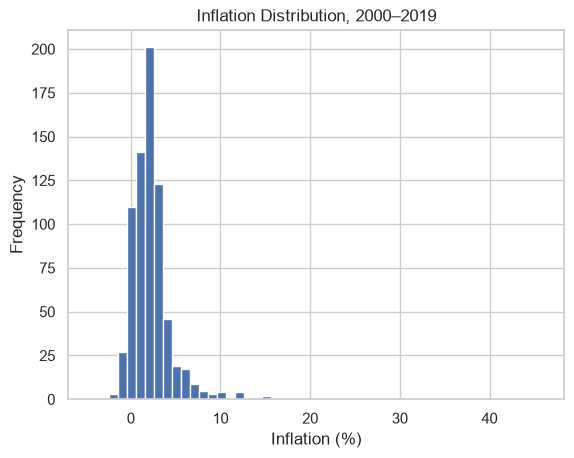

In [9]:
df_period["inflation"].hist(bins=50)
plt.xlabel("Inflation (%)")
plt.ylabel("Frequency")
plt.title("Inflation Distribution, 2000–2019")

Text(0.5, 1.0, 'Inflation, 2000–2019')

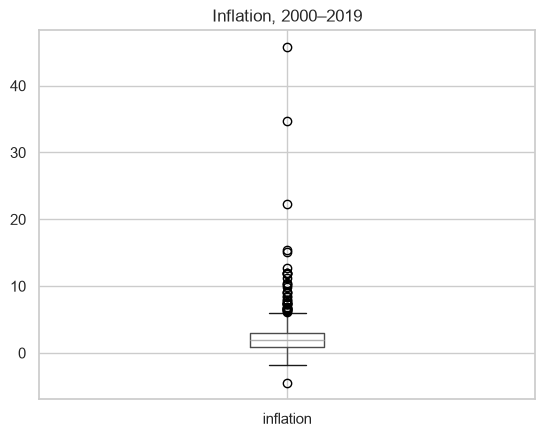

In [10]:
df_period.boxplot(column="inflation")
plt.title("Inflation, 2000–2019")

In [11]:
df_period.nlargest(10, "inflation")[
    ["country", "year", "inflation"]
]

,country,year,inflation
1507,Romania,2000,45.833333
1508,Romania,2001,34.642857
1509,Romania,2002,22.281167
1510,Romania,2003,15.401302
1053,Latvia,2008,15.170670
830,Iceland,2008,12.694402
1541,Slovakia,2000,12.035777
831,Iceland,2009,12.003117
210,Bulgaria,2008,11.980440
1511,Romania,2004,11.842105


The inflation variable is strongly right-skewed. Most observations between 2000 and 2019 are concentrated at relatively low inflation rates, while several country-year observations show substantially higher inflation. The boxplot identifies these observations as statistical outliers according to the IQR rule, but they are not necessarily data errors and should not be removed without further investigation.

--
After verifying the data with the world data bank, we can conclude that 45.8% inflation in romania is an accurate value(even though its unusual, so we can keep it), since previos peack of inflation in 1993 was even bigger

---
## 3. Design your tables

Decide what your tables are and how they relate before you write any code. Draw the ERD (Excalidraw, draw.io), export it as an image, commit it, and link it from your README.

Three tables minimum, with real primary and foreign keys.

---
## 4. Build the tables

Split the cleaned data into the tables you designed.

---
## 5. Check the foreign keys

**Do not skip this.** A dangling foreign key is the failure that costs people their Wednesday: the database loads without an error, then your joins silently drop rows and every number is quietly wrong. Check every key value exists in its parent table before you load anything.

---
## 6. Create the database and load it

Write your `CREATE TABLE` statements in `sql/schema.sql`, then load the tables — parents before children, or the foreign keys will be rejected.

---
## 7. Verify

Row counts per table, and one join that returns the rows you expect. Then open `data/project.db` in DB Browser and look at it.